In [54]:
2 * np.pi / (24 * 3600 * 365.25)

1.991021277657232e-07

In [102]:
# Example of chaotic migration using dynamical tides operator
import rebound
import reboundx
from matplotlib import pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams.update({'font.size': 14})

# intial conditions
a0 = 1.5
e0 = 0.1
R_star = 4.65e-3 # 1 solar radius
R_planet = 1.6 * 4.67e-4 # 1.6 Jupiter radii
m_planet = 1e-3 # approximately 1 Jupiter mass

# create simulation
sim = rebound.Simulation()
sim.add(m=1, r = R_star)
sim.add(m=m_planet, r=R_planet, a=a0, e=e0)
sim.add(m=1, a=100, inc=87 * np.pi / 180)

# load reboundx and the dynamical tides operator
rebx = reboundx.Extras(sim)
td = rebx.load_operator('tides_dynamical')
rebx.add_operator(td)

# load tides_constant_time_lag
time_lag = rebx.load_force("tides_constant_time_lag")
#rebx.add_force(time_lag)
sim.particles[0].params['tctl_k2'] = 0.03
sim.particles[1].params['tctl_k2'] = 0.25
sim.particles[1].params['tctl_tau'] = 1e-2

# set dP_crit = 0 to always carry out mode evolution
sim.particles[1].params['td_dP_crit'] = 0

# set initial modes to 0
sim.particles[1].params['td_c_imag'] = 0
sim.particles[1].params['td_c_real'] = 0

# record initial orbital energy
o = sim.particles[1].orbit(primary=sim.particles[0])
EB0 = -sim.G * sim.particles[1].m * sim.particles[0].m / (2 * o.a)

N = 100000
t = np.linspace(0, 1.6e5, N) # time
a = np.zeros(N) # semi-major axis
e = np.zeros(N) # eccenricity
E = np.zeros(N) # mode energy
E_sim = np.zeros(N) # simulation energy
L = np.zeros((N, 3)) # total angular momentum
inc = np.zeros(N)

dEs = []
Ms = []

def heartbeat(sim_pointer):
    # read dE if close to pericenter
    sim = sim_pointer.contents
    o = sim.particles[1].orbit(primary=sim.particles[0])

    if sim.particles[1].params['td_num_periapse'] > 1:
        dP_hat = sim.particles[1].params['td_dP_hat']
        M_thresh = 0.1
        if dP_hat >= 1 and ((2*np.pi - o.M) <= M_thresh or o.M <= M_thresh):
            dEs.append(sim.particles[1].params['td_dE_last'])
            Ms.append(o.M)

#sim.heartbeat = heartbeat

for i, time in enumerate(t):
    o = sim.particles[1].orbit(primary=sim.particles[0])
    a[i] = o.a
    e[i] = o.e
    L[i, :] = sim.angular_momentum() 
    E[i] = abs(EB0) * (sim.particles[1].params['td_c_imag']**2 + sim.particles[1].params['td_c_real']**2)
    inc[i] = o.inc
    E_sim[i] = sim.energy()

    if i % 10 == 0 and i != 0:
        print(time, o.a, o.e, E[i], sim.particles[1].params['td_dP_hat'], len(dEs))
    
    sim.integrate(2 * np.pi * time)
    



Exception ignored on calling ctypes callback function: <function heartbeat at 0x7f5d3db3fc40>
Traceback (most recent call last):
  File "/tmp/ipykernel_5533/335619934.py", line 62, in heartbeat
  File "/mnt/c/users/moody/documents/github/reboundx/reboundx/params.py", line 55, in __getitem__
    raise AttributeError("REBOUNDx Error: Parameter '{0}' not found on object.".format(key))
AttributeError: REBOUNDx Error: Parameter 'td_num_periapse' not found on object.
Exception ignored on calling ctypes callback function: <function heartbeat at 0x7f5d3db3fc40>
Traceback (most recent call last):
  File "/tmp/ipykernel_5533/335619934.py", line 62, in heartbeat
  File "/mnt/c/users/moody/documents/github/reboundx/reboundx/params.py", line 55, in __getitem__
    raise AttributeError("REBOUNDx Error: Parameter '{0}' not found on object.".format(key))
AttributeError: REBOUNDx Error: Parameter 'td_num_periapse' not found on object.


16.000160001600015 1.4999891795750653 0.09999523235341684 0.0 0.0 0
32.00032000320003 1.5000017101178227 0.09998595306135316 0.0 0.0 0
48.00048000480005 1.499988849073552 0.09998969689274437 0.0 0.0 0
64.00064000640006 1.4999984597289864 0.09999266438399779 0.0 0.0 0
80.00080000800008 1.499992206666203 0.09998234664188185 0.0 0.0 0
96.0009600096001 1.4999961499340642 0.09997682399569481 0.0 0.0 0
112.00112001120011 1.4999943820171018 0.09997973098850813 0.0 0.0 0
128.00128001280012 1.4999936053791902 0.09997500309695709 0.0 0.0 0
144.00144001440015 1.4999945044453178 0.09996721624709316 0.0 0.0 0
160.00160001600017 1.4999940696964158 0.09996823003153402 0.0 0.0 0
176.0017600176002 1.4999954371740138 0.0999706643162135 0.0 0.0 0
192.0019200192002 1.4999939362979178 0.09996602510050294 0.0 0.0 0
208.0020800208002 1.4999941643767976 0.09996498932249952 0.0 0.0 0
224.00224002240023 1.4999945033619266 0.09997219948420473 0.0 0.0 0
240.00240002400025 1.4999935408435994 0.09997465580977573 0.

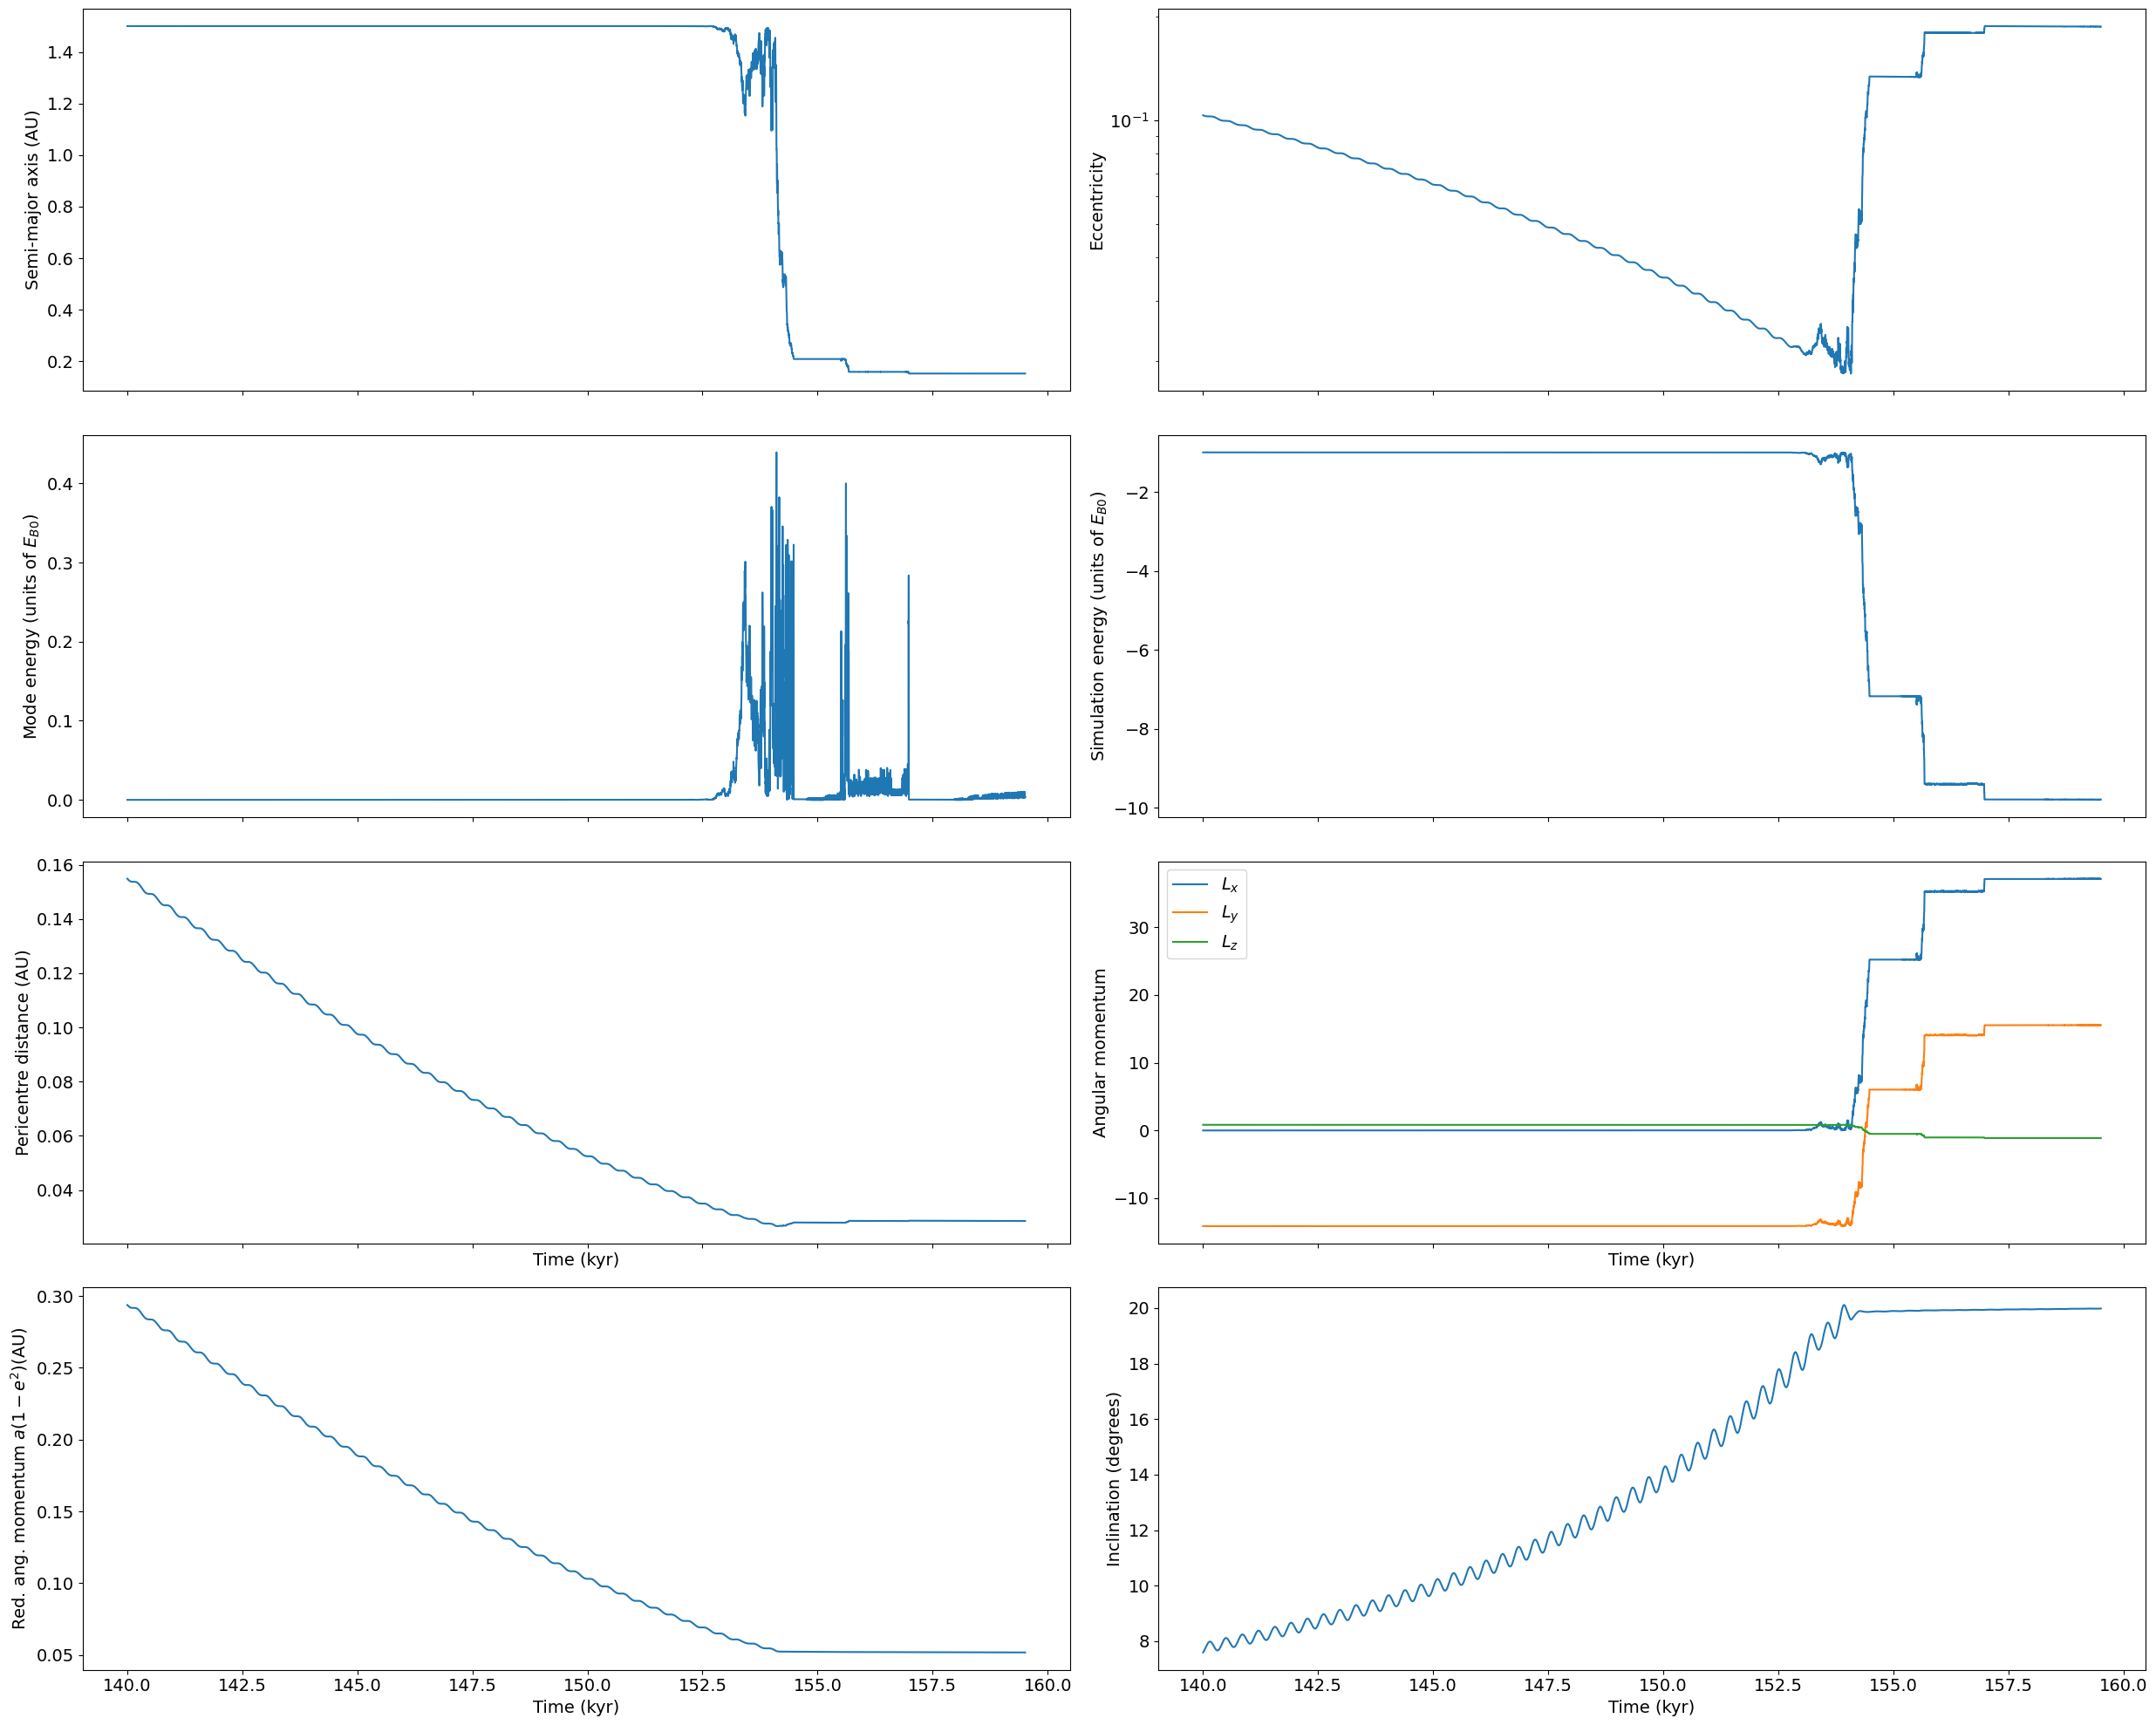

In [99]:
fig, axes = plt.subplots(4, 2, sharex=True)
fig.set_figheight(20)
fig.set_figwidth(25)

indices = np.logical_and(np.logical_and(e != 0, t >= 1.4e5), t<=1.6e5)


axes[0, 0].plot(t[indices] / 1e3, a[indices])
axes[0, 0].set_ylabel(r'Semi-major axis (AU)')

axes[0, 1].plot(t[indices] / 1e3, 1 - e[indices])
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel(r'Eccentricity')

axes[1, 0].plot(t[indices] / 1e3, -E[indices] / EB0)
axes[1, 0].set_ylabel(r'Mode energy (units of $E_{B0}$)')

axes[1, 1].plot(t[indices] / 1e3, -E_sim [indices]/ EB0)
axes[1, 1].set_ylabel(r'Simulation energy (units of $E_{B0}$)')

axes[2, 0].plot(t[indices] / 1e3, a[indices] * (1-e[indices]))
axes[2, 0].set_ylabel(r'Pericentre distance (AU)')
axes[2, 0].set_xlabel(r'Time (kyr)')

axes[2, 1].plot(t[indices] / 1e3, L[:,0][indices], label=r'$L_x$')
axes[2, 1].plot(t[indices] / 1e3, L[:,1][indices], label=r'$L_y$')
axes[2, 1].plot(t[indices] / 1e3, L[:,2][indices], label=r'$L_z$')
axes[2, 1].set_ylabel('Angular momentum')
axes[2, 1].legend()
axes[2, 1].set_xlabel(r'Time (kyr)')

axes[3, 0].plot(t[indices] / 1e3, a[indices] * (1-e[indices]**2))
axes[3, 0].set_ylabel(r'Red. ang. momentum $a(1-e^2)$(AU)')
axes[3, 0].set_xlabel(r'Time (kyr)')

axes[3, 1].plot(t[indices] / 1e3, inc[indices] * 180 / np.pi)
axes[3, 1].set_ylabel(r'Inclination (degrees)')
axes[3, 1].set_xlabel(r'Time (kyr)')

plt.tight_layout()
plt.savefig("Angular momentum non-conservation.png", dpi=150)

Text(0.5, 0, '$M$')

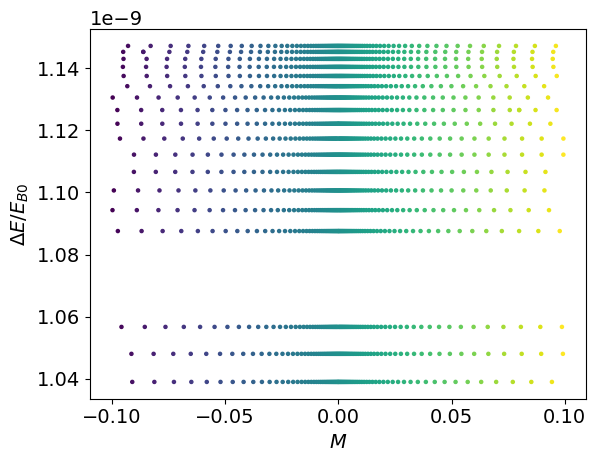

In [137]:
cutoff = 1479

Ms2 = np.array(Ms)[:cutoff]
dEs2 = np.array(dEs)[:cutoff]

Ms2[Ms2 >= 6] = Ms2[Ms2 >= 6] - 2 * np.pi 

plt.scatter(Ms2, dEs2, s=5, c=Ms2)
plt.ylabel(r"$\Delta E / E_{B0}$")
plt.xlabel(r"$M$")
plt.savefig()